In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/forest-cover-type-dataset/covtype.csv


In [44]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "covtype.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/forest-cover-type-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_55/1733191385.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234  

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Separando a coluna Cover Type -- > Alvo
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

#Normalizar dados
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X.astype(np.float64))

#Divisão treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Criando alvo binário
y_train_lodgepole = (y_train == 2)
y_test_lodgepole = (y_test == 2)

In [47]:
from sklearn.linear_model import SGDClassifier

#Usamos random_state para reprodutibilidade
sgd_clf = SGDClassifier(random_state=42, loss='hinge', class_weight='balanced')
sgd_clf.fit(X_train, y_train_lodgepole)

SGDClassifier(class_weight='balanced', random_state=42)

In [54]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

#Predições via Cross-Validation
y_sgd_pred = cross_val_predict(sgd_clf, X_train, y_train_lodgepole, cv=3)

print("Matriz de Confusão:\n", confusion_matrix(y_train_lodgepole, y_sgd_pred))
print(f"Precisão: {precision_score(y_train_lodgepole, y_sgd_pred):.2f}")
print(f"Recall: {recall_score(y_train_lodgepole, y_sgd_pred):.2f}")
print(f"F1-Score: {f1_score(y_train_lodgepole, y_sgd_pred):.2f}")

Matriz de Confusão:
 [[175475  62533]
 [ 50289 176512]]
Precisão: 0.74
Recall: 0.78
F1-Score: 0.76


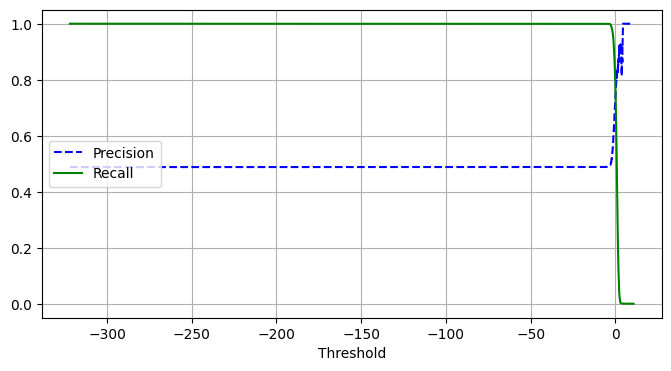

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Pegando os scores (distâncias da fronteira de decisão)
y_scores = cross_val_predict(sgd_clf, X_train, y_train_lodgepole, cv=3, method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_lodgepole, y_scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend(loc="center left")
plt.grid(True)
plt.show()

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

#Usa o RandomForest
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#Treinando
forest_clf.fit(X_train, y_train_lodgepole)

              precision    recall  f1-score   support

       False       0.97      0.95      0.96     59703
        True       0.95      0.97      0.96     56500

    accuracy                           0.96    116203
   macro avg       0.96      0.96      0.96    116203
weighted avg       0.96      0.96      0.96    116203



In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_forest_pred = cross_val_predict(forest_clf, X_train, y_train_lodgepole, cv=3)

print("Matriz de Confusão:\n", confusion_matrix(y_train_lodgepole, y_forest_pred))
print(f"Precisão: {precision_score(y_train_lodgepole, y_forest_pred):.2f}")
print(f"Recall: {recall_score(y_train_lodgepole, y_forest_pred):.2f}")
print(f"F1-Score: {f1_score(y_train_lodgepole, y_forest_pred):.2f}")

Matriz de Confusão:
 [[224892  13116]
 [  8238 218563]]
Precisão: 0.94
Recall: 0.96
F1-Score: 0.95
